# Entendimento do negócio

In [215]:
# Importações
import ee
import requests
import re
import os
import urllib3
import zipfile
import shutil
import json

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

from glob import glob
from io import BytesIO
from shapely.geometry import box

print("OK")

OK


In [216]:
# Roda o comando no terminal : earthengine authenticate --auth_mode=notebook
ee.Authenticate()
ee.Initialize(project="spatial-yew-490017-r3")
print(ee.String("Hello from the Earth Engine servers!").getInfo())

Hello from the Earth Engine servers!


In [217]:
# mostrar todas as colunas
pd.set_option('display.max_columns', None)

# não quebrar a largura da tabela
pd.set_option('display.expand_frame_repr', False)

# opcional: aumentar a largura máxima exibida
pd.set_option('display.width', 1000)

# Entendimento dos dados

In [218]:
FILES_DIR = "files"

os.makedirs(FILES_DIR, exist_ok=True)

In [219]:
# Download UCs boundaries via WFS (INDE/ICMBio)

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

ucs_dir = os.path.join(FILES_DIR, "limites_ucs")
os.makedirs(ucs_dir, exist_ok=True)

uc_typename = "ICMBio:limiteucsfederais_a"
uc_output_path = os.path.join(ucs_dir, "limites_ucs.geojson")

if os.path.exists(uc_output_path):
    print(f"Already downloaded: {uc_output_path}")
else:
    wfs_url = (
        "https://geoservicos.inde.gov.br/geoserver/ICMBio/ows"
        f"?service=WFS&version=2.0.0&request=GetFeature"
        f"&typeName={uc_typename}&outputFormat=application/json"
    )
    response = requests.get(wfs_url, timeout=180, verify=False)
    response.raise_for_status()
    with open(uc_output_path, 'wb') as f:
        f.write(response.content)
    print(f"Saved: {uc_output_path}")

gdf_ucs = gpd.read_file(uc_output_path)

print("Shape:", gdf_ucs.shape)
print("Columns:", gdf_ucs.columns.tolist())
print("CRS:", gdf_ucs.crs)

Already downloaded: files\limites_ucs\limites_ucs.geojson
Shape: (347, 22)
Columns: ['ogc_fid', 'id', 'nomeuc', 'cnuc', 'criacaoano', 'areahaalb', 'perimm', 'criacaoato', 'esferaadm', 'grupouc', 'biomas', 'gregional', 'fusoabrang', 'demarcacao', 'escalauc', 'bioma_pred', 'cat_iucn', 'uf', 'categoria_', 'sigla_cate', 'dominio', 'geometry']
CRS: EPSG:4674


In [220]:
# INPE hotspots — reference satellite, multi-year range

INPE_YEARS = [2003, 2025]  # single year: [2025]; range: [start, end]

inpe_years_to_download = (
    INPE_YEARS if len(INPE_YEARS) == 1
    else list(range(min(INPE_YEARS), max(INPE_YEARS) + 1))
)
print("INPE years queued:", inpe_years_to_download)

INPE years queued: [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [221]:
# INPE FOCO DE CALOR - downlaod de range de ano
inpe_dir = os.path.join(FILES_DIR, "inpe_focos")
os.makedirs(inpe_dir, exist_ok=True)

inpe_downloaded_files = {}

for year in inpe_years_to_download:

    csv_filename = f"focos_br_ref_{year}.csv"
    csv_path = os.path.join(inpe_dir, csv_filename)

    if os.path.exists(csv_path):
        print(f"[{year}] Already downloaded")
        inpe_downloaded_files[year] = csv_path
        continue

    zip_url = f"https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/Brasil_todos_sats/focos_br_todos-sats_{year}.zip"

    try:
        response = requests.get(zip_url, timeout=180)
        response.raise_for_status()

        tmp_dir = os.path.join(inpe_dir, f"tmp_{year}")
        os.makedirs(tmp_dir, exist_ok=True)

        with zipfile.ZipFile(BytesIO(response.content)) as z:
            z.extractall(tmp_dir)

        found_csvs = glob(os.path.join(tmp_dir, "**", "*.csv"), recursive=True)

        if found_csvs:
            shutil.move(found_csvs[0], csv_path)
            inpe_downloaded_files[year] = csv_path
        else:
            print(f"[{year}] No CSV found in zip")

        shutil.rmtree(tmp_dir, ignore_errors=True)

    except requests.exceptions.RequestException:
        print(f"[{year}] Download failed")

print("Done:", list(inpe_downloaded_files.keys()))

[2003] Already downloaded
[2004] Already downloaded
[2005] Already downloaded
[2006] Already downloaded
[2007] Already downloaded
[2008] Already downloaded
[2009] Already downloaded
[2010] Already downloaded
[2011] Already downloaded
[2012] Already downloaded
[2013] Already downloaded
[2014] Already downloaded
[2015] Already downloaded
[2016] Already downloaded
[2017] Already downloaded
[2018] Already downloaded
[2019] Already downloaded
[2020] Already downloaded
[2022] Already downloaded
[2023] Already downloaded
[2024] Already downloaded
Done: [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [222]:
inpe_df_list = []

for year, path in inpe_downloaded_files.items():
    df_year = pd.read_csv(path)
    df_year['file_year'] = year
    inpe_df_list.append(df_year)

df_inpe = pd.concat(inpe_df_list, ignore_index=True)

print("Shape:", df_inpe.shape)
print("Columns:", df_inpe.columns.tolist())
print("Years present:", sorted(df_inpe['file_year'].unique()))

Shape: (57341032, 14)
Columns: ['latitude', 'longitude', 'data_pas', 'satelite', 'pais', 'estado', 'municipio', 'bioma', 'numero_dias_sem_chuva', 'precipitacao', 'risco_fogo', 'id_area_industrial', 'frp', 'file_year']
Years present: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [223]:
# AAF — download via ArcGIS FeatureServer (anos 2010-2026)

BASE_URL = "https://services3.arcgis.com/KYEMegXJrTiWSYWk/arcgis/rest/services"
PAGE_SIZE = 2000

aaf_urls_by_year = {}

# Padrão dinâmico — anos 2010 a 2022 seguem a mesma convenção de nome
for year in range(2010, 2023):
    aaf_urls_by_year[year] = f"{BASE_URL}/db_geo_compartilhado_dmif_fogo_aaf_{year}/FeatureServer/0"

# Exceções — nomes de serviço mudaram ano a ano a partir de 2023
aaf_urls_by_year[2023] = f"{BASE_URL}/AAF_2023_DGEO_ICMBIO_oficial/FeatureServer/0"
aaf_urls_by_year[2024] = f"{BASE_URL}/AAF_2024_DGEO_ICMBIO_oficial/FeatureServer/0"
aaf_urls_by_year[2025] = f"{BASE_URL}/AAF_2025_DGEO_oficial/FeatureServer/0"
aaf_urls_by_year[2026] = f"{BASE_URL}/AAF_2026/FeatureServer/0"

print("Total de anos mapeados:", len(aaf_urls_by_year))

Total de anos mapeados: 17


In [224]:
# Download com paginação, salvando um GeoJSON por ano

aaf_dir = os.path.join(FILES_DIR, "aaf")
os.makedirs(aaf_dir, exist_ok=True)

aaf_downloaded_files = {}

for year, base_url in aaf_urls_by_year.items():

    output_path = os.path.join(aaf_dir, f"aaf_{year}.geojson")

    if os.path.exists(output_path):
        print(f"[{year}] Já baixado")
        aaf_downloaded_files[year] = output_path
        continue

    print(f"[{year}] Baixando")

    # Paginação — segue baixando enquanto o servidor retornar página cheia
    all_features = []
    offset = 0

    while True:
        query_url = (
            f"{base_url}/query?where=1%3D1&outFields=*&outSR=4326&f=geojson"
            f"&resultOffset={offset}&resultRecordCount={PAGE_SIZE}"
        )
        response = requests.get(query_url, timeout=120)
        response.raise_for_status()
        page_data = response.json()

        features = page_data.get('features', [])
        if not features:
            break

        all_features.extend(features)

        if len(features) < PAGE_SIZE:
            break

        offset += PAGE_SIZE

    # Salvar como GeoJSON válido
    final_geojson = {"type": "FeatureCollection", "features": all_features}

    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(final_geojson, f)

    aaf_downloaded_files[year] = output_path
    print(f"[{year}] Salvo — {len(all_features)} registros")

print("\nAnos baixados:", list(aaf_downloaded_files.keys()))

[2010] Já baixado
[2011] Já baixado
[2012] Já baixado
[2013] Já baixado
[2014] Já baixado
[2015] Já baixado
[2016] Já baixado
[2017] Já baixado
[2018] Já baixado
[2019] Já baixado
[2020] Já baixado
[2021] Já baixado
[2022] Já baixado
[2023] Já baixado
[2024] Já baixado
[2025] Já baixado
[2026] Já baixado

Anos baixados: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


In [225]:
# Carregar todos os anos, checando consistência de colunas antes de concatenar

aaf_gdf_list = []
reference_columns = None

for year, path in aaf_downloaded_files.items():
    gdf_year = gpd.read_file(path)

    if reference_columns is None:
        reference_columns = set(gdf_year.columns)
    else:
        diff = set(gdf_year.columns).symmetric_difference(reference_columns)
        if diff:
            print(f"[{year}] Diferença de colunas em relação ao primeiro ano: {diff}")

    gdf_year['file_year'] = year
    aaf_gdf_list.append(gdf_year)

gdf_aaf = gpd.GeoDataFrame(pd.concat(aaf_gdf_list, ignore_index=True))


print("Shape:", gdf_aaf.shape)
print("Colunas:", gdf_aaf.columns.tolist())
print("Anos presentes:", sorted(gdf_aaf['file_year'].unique()))

[2024] Diferença de colunas em relação ao primeiro ano: {'area_uc', 'gr_nome', 'data_img', 'ano', 'data', 'ct', 'area_ent', 'mes_nome', 'cr', 'mes_num', 'GlobalID', 'ngi', 'bioma', 'FID', 'categoria', 'pk_aaf', 'local'}
[2025] Diferença de colunas em relação ao primeiro ano: {'area_uc', 'gr_nome', 'data_img', 'data', 'ct', 'ano', 'Shape__Len', 'Shape__Are', 'area_ent', 'mes_nome', 'classe', 'cr', 'mes_num', 'GlobalID', 'tipo', 'ngi', 'bioma', 'acao', 'FID', 'categoria', 'pk_aaf', 'local'}
[2026] Diferença de colunas em relação ao primeiro ano: {'area_uc', 'gr_nome', 'data_img', 'data', 'ct', 'ano', 'GlobalID_2', 'Shape__Len', 'Shape__Are', 'area_ent', 'mes_nome', 'classe', 'cr', 'mes_num', 'GlobalID', 'tipo', 'ngi', 'bioma', 'acao', 'FID', 'categoria', 'pk_aaf', 'local'}
Shape: (41571, 33)
Colunas: ['pk_aaf', 'cnuc', 'nome_uc', 'area_ha', 'data_img', 'classe', 'satelite', 'obs', 'juliano', 'Shape__Area', 'Shape__Length', 'geometry', 'file_year', 'FID', 'data', 'ano', 'mes_nome', 'mes_n

In [226]:
# Harmonizar colunas divergentes entre eras do schema

gdf_aaf["event_year"] = gdf_aaf["file_year"]

# converter cada fonte para datetime
date_from_old_schema = pd.to_datetime(gdf_aaf["data"], unit="ms", errors="coerce")
date_from_new_schema = pd.to_datetime(gdf_aaf["data_img"], errors="coerce")
gdf_aaf["event_date"] = date_from_old_schema.combine_first(date_from_new_schema)

#  recupera datas quando 'data' e 'data_img' estão ausentes
julian_fallback = pd.to_datetime(
    gdf_aaf["file_year"].astype(str), format="%Y", errors="coerce"
) + pd.to_timedelta(gdf_aaf["juliano"] - 1, unit="D")
gdf_aaf["event_date"] = gdf_aaf["event_date"].combine_first(julian_fallback)
gdf_aaf["event_month"] = gdf_aaf["event_date"].dt.month

# coalesce entre nomenclatura abreviada e completa
gdf_aaf["shape_area"] = gdf_aaf["Shape__Are"].combine_first(gdf_aaf["Shape__Area"])
gdf_aaf["shape_length"] = gdf_aaf["Shape__Len"].combine_first(gdf_aaf["Shape__Length"])

# Descartar eventos sem data válida
n_before = len(gdf_aaf)
gdf_aaf = gdf_aaf[gdf_aaf["event_date"].notna()].copy()

print(
    f"Eventos descartados por falta de data: {n_before - len(gdf_aaf)} ({(n_before - len(gdf_aaf)) / n_before * 100:.1f}%)"
)
print(f"Total de eventos final: {len(gdf_aaf)}")
print(f"Nulos em shape_area: {gdf_aaf['shape_area'].isna().sum()}")

Eventos descartados por falta de data: 386 (0.9%)
Total de eventos final: 41185
Nulos em shape_area: 1


# Preparação dos dados

In [227]:
METRIC_CRS = "EPSG:5880"  # SIRGAS 2000 / Brazil Polyconic
CELL_SIZE_M = 5000        # 5km x 5km, ajustável

In [228]:
#  Reprojetar UCs e AAF para CRS métrico

gdf_ucs_metric = gdf_ucs.to_crs(METRIC_CRS)
gdf_aaf_metric = gdf_aaf.to_crs(METRIC_CRS)

print("CRS UCs após reprojeção:", gdf_ucs_metric.crs)
print("CRS AAF após reprojeção:", gdf_aaf_metric.crs)


CRS UCs após reprojeção: EPSG:5880
CRS AAF após reprojeção: EPSG:5880


In [229]:
# Validar geometrias

gdf_ucs_metric['geometry'] = gdf_ucs_metric.geometry.buffer(0)
gdf_aaf_metric['geometry'] = gdf_aaf_metric.geometry.buffer(0)

print("\nApós correção com buffer(0):")
print("Geometrias inválidas em gdf_ucs_metric:", (~gdf_ucs_metric.is_valid).sum())
print("Geometrias inválidas em gdf_aaf_metric:", (~gdf_aaf_metric.is_valid).sum())


Após correção com buffer(0):
Geometrias inválidas em gdf_ucs_metric: 0
Geometrias inválidas em gdf_aaf_metric: 2


In [230]:
# Descartar volume irrelevante
n_before = len(gdf_aaf_metric)
gdf_aaf_metric = gdf_aaf_metric[gdf_aaf_metric.is_valid].copy()

print(f"\nRegistros descartados por geometria inválida: {n_before - len(gdf_aaf_metric)}")
print(f"Total de eventos final: {len(gdf_aaf_metric)}")


Registros descartados por geometria inválida: 2
Total de eventos final: 41183


In [231]:
# Remover as poucas duplicatas geométricas reais (0.6% do total)
n_before = len(gdf_aaf_metric)
gdf_aaf_metric = gdf_aaf_metric[
    ~gdf_aaf_metric.geometry.apply(lambda g: g.wkb).duplicated()
].copy()

print(f"Duplicatas geométricas removidas: {n_before - len(gdf_aaf_metric)}")
print(f"Total final: {len(gdf_aaf_metric)}")

Duplicatas geométricas removidas: 238
Total final: 40945


In [232]:
# Origem global fixa 
global_minx, global_miny, _, _ = gdf_ucs_metric.total_bounds

grid_records = []

for idx, row in gdf_ucs_metric.iterrows():
    uc_geom = row.geometry
    minx, miny, maxx, maxy = uc_geom.bounds

    # índices de célula alinhados à origem global, mas o loop roda só no bbox pequeno desta UC
    i_start = int((minx - global_minx) // CELL_SIZE_M)
    i_end = int((maxx - global_minx) // CELL_SIZE_M) + 1
    j_start = int((miny - global_miny) // CELL_SIZE_M)
    j_end = int((maxy - global_miny) // CELL_SIZE_M) + 1

    for i in range(i_start, i_end):
        for j in range(j_start, j_end):
            cell_x = global_minx + i * CELL_SIZE_M
            cell_y = global_miny + j * CELL_SIZE_M
            cell = box(cell_x, cell_y, cell_x + CELL_SIZE_M, cell_y + CELL_SIZE_M)

            if uc_geom.intersects(cell):
                clipped = uc_geom.intersection(cell)
                if not clipped.is_empty:
                    grid_records.append({'cell_id': f"{i}_{j}", 'geometry': clipped})

gdf_grid_raw = gpd.GeoDataFrame(grid_records, crs=METRIC_CRS)
print("Peças de célula geradas (antes de fundir sobreposições):", len(gdf_grid_raw))

# Fundir peças que compartilham o mesmo cell_id (onde UCs se sobrepõem) numa única geometria
gdf_grid = gdf_grid_raw.dissolve(by='cell_id', as_index=False)

print("Total de células globais únicas:", len(gdf_grid))

Peças de célula geradas (antes de fundir sobreposições): 85195
Total de células globais únicas: 82045


In [233]:
# Tabela de associação de célula UC. 

cell_uc_membership = gpd.sjoin(
    gdf_grid,
    gdf_ucs_metric[['cnuc', 'geometry']],
    how='left',
    predicate='intersects'
)[['cell_id', 'cnuc']]

cells_per_uc_count = cell_uc_membership.groupby('cell_id').size()
print("Células que pertencentes a mais de um UC:", (cells_per_uc_count > 1).sum())
print(cell_uc_membership.head())

Células que pertencentes a mais de um UC: 3064
    cell_id          cnuc
0     0_575  0000.00.0149
1     0_576  0000.00.0149
2     0_579  0000.00.0149
3     0_580  0000.00.0149
4  1000_189  0000.00.3633


In [234]:
# Atribua eventos AAF a células da grade via sobreposição 

gdf_aaf_clipped = gpd.overlay(
    gdf_aaf_metric,
    gdf_grid[['cell_id', 'geometry']],
    how='intersection'
)

gdf_aaf_clipped['area_ha_cell'] = gdf_aaf_clipped.geometry.area / 10000

print("Eventos originais da AAF:", len(gdf_aaf_metric))
print("Linhas após a sobreposição (evento dividido por célula):", len(gdf_aaf_clipped))


c:\Users\ANDERSONALVESCOELHO\anaconda3\envs\geo\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 4 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


Eventos originais da AAF: 40945
Linhas após a sobreposição (evento dividido por célula): 83642


In [235]:
gdf_aaf_clipped[['nome_uc', 'event_year', 'area_ha', 'area_ha_cell', 'cell_id']].head()

,nome_uc,event_year,area_ha,area_ha_cell,cell_id
0,APA Morro da Pedreira,2011,217.3214,11.464956,658_323
1,APA Morro da Pedreira,2011,217.3214,3.045426,658_324
2,APA Morro da Pedreira,2011,217.3214,183.377438,659_323
3,APA Morro da Pedreira,2011,217.3214,22.627761,659_324
4,APA Morro da Pedreira,2011,268.8861,272.857686,659_319


In [238]:
# Atribuir foco de calor INPE às células da grade (ponto — sem necessidade de overlay)

gdf_inpe_points = gpd.GeoDataFrame(
    df_inpe,
    geometry=gpd.points_from_xy(df_inpe['longitude'], df_inpe['latitude']),
    crs="EPSG:4326"
).to_crs(METRIC_CRS)

gdf_inpe_with_cell = gpd.sjoin(
    gdf_inpe_points,
    gdf_grid[['cell_id', 'geometry']],
    how='inner',
    predicate='within'
)

print("Total de focos INPE:", len(gdf_inpe_points))
print("Focos dentro de alguma célula:", len(gdf_inpe_with_cell))

Total de focos INPE: 57341032
Focos dentro de alguma célula: 2565609


# Análise exploratória de dados (EDA)

In [239]:
print("Total de eventos:", len(gdf_aaf_metric))
print("\nColunas disponíveis:\n", gdf_aaf_metric.columns.tolist())

Total de eventos: 40945

Colunas disponíveis:
 ['pk_aaf', 'cnuc', 'nome_uc', 'area_ha', 'data_img', 'classe', 'satelite', 'obs', 'juliano', 'Shape__Area', 'Shape__Length', 'geometry', 'file_year', 'FID', 'data', 'ano', 'mes_nome', 'mes_num', 'categoria', 'local', 'area_uc', 'area_ent', 'bioma', 'gr_nome', 'ngi', 'cr', 'GlobalID', 'ct', 'acao', 'tipo', 'Shape__Are', 'Shape__Len', 'GlobalID_2', 'event_year', 'event_date', 'event_month', 'shape_area', 'shape_length']


In [240]:
gdf_aaf_metric.head(5)

,pk_aaf,cnuc,nome_uc,area_ha,data_img,classe,satelite,obs,juliano,Shape__Area,Shape__Length,geometry,file_year,FID,data,ano,mes_nome,mes_num,categoria,local,area_uc,area_ent,bioma,gr_nome,ngi,cr,GlobalID,ct,acao,tipo,Shape__Are,Shape__Len,GlobalID_2,event_year,event_date,event_month,shape_area,shape_length
354,1.0,0000.00.0027,APA Morro da Pedreira,217.3214,2011-08-17 00:00:00,None,modis_aqua,None,229,0.000187,0.117502,"POLYGON ((6090006.554 7854634.656, 6089954.03 ...",2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-17,8.0,0.000187,0.117502
355,2.0,0000.00.0027,APA Morro da Pedreira,268.8861,2011-08-24 00:00:00,None,modis_terra,None,236,0.000231,0.066348,"POLYGON ((6093280.905 7834230.006, 6093316 783...",2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-24,8.0,0.000231,0.066348
356,3.0,0000.00.0027,APA Morro da Pedreira,124.4476,2011-08-26 00:00:00,None,modis_terra,None,238,0.000107,0.049803,"POLYGON ((6093280.905 7834230.006, 6092838.536...",2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-26,8.0,0.000107,0.049803
357,4.0,0000.00.0027,APA Morro da Pedreira,80.7516,2011-08-26 00:00:00,None,modis_terra,None,238,0.000069,0.047572,"POLYGON ((6090200.571 7836459.571, 6090747.715...",2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-26,8.0,0.000069,0.047572
358,5.0,0000.00.0027,APA Morro da Pedreira,179.2940,2011-08-13 00:00:00,None,modis_aqua,None,225,0.000154,0.052651,"POLYGON ((6095979.381 7851422.831, 6095364.862...",2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011,2011-08-13,8.0,0.000154,0.052651


bioma
NaN                 28554
CERRADO              7933
AMAZÔNIA             2746
PANTANAL              848
MATA ATLÂNTICA        776
CAATINGA               77
PAMPA                  10
MARINHO COSTEIRO        1
Name: count, dtype: int64


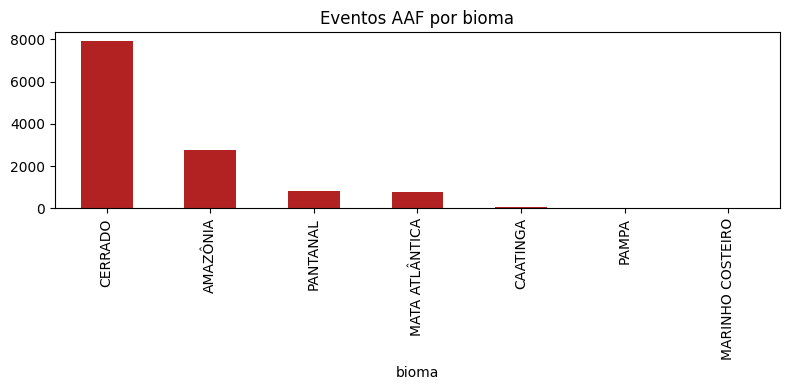

In [241]:
# Distribuição por bioma
print(gdf_aaf_metric['bioma'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
gdf_aaf_metric['bioma'].value_counts().plot(kind='bar', color='firebrick')
plt.title('Eventos AAF por bioma')
plt.tight_layout()
plt.show()

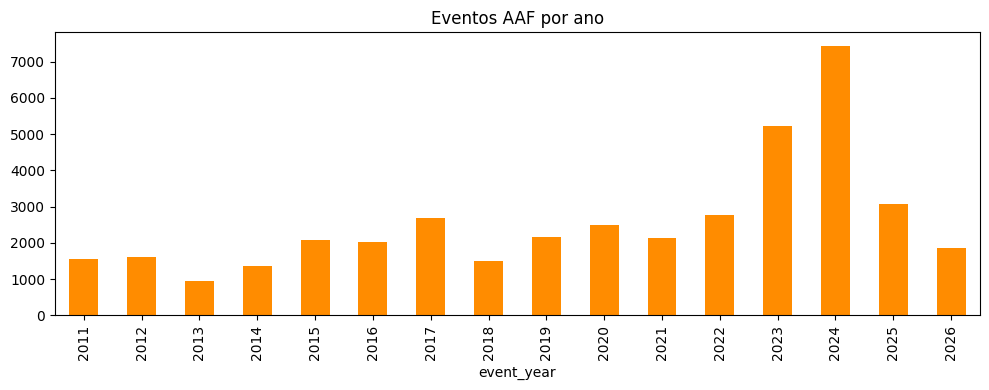

In [242]:
# Distribuição por ano
eventos_por_ano = gdf_aaf_metric['event_year'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
eventos_por_ano.plot(kind='bar', color='darkorange')
plt.title('Eventos AAF por ano')
plt.tight_layout()
plt.show()

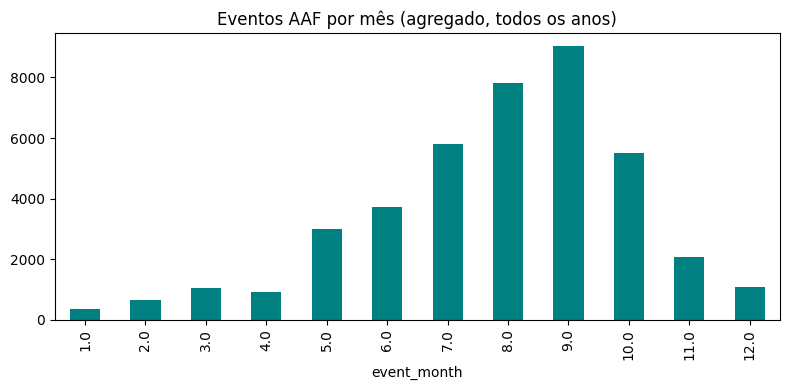

In [243]:
# Distribuição por mês (todos os anos agregados)

eventos_por_mes = gdf_aaf_metric['event_month'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
eventos_por_mes.plot(kind='bar', color='teal')
plt.title('Eventos AAF por mês (agregado, todos os anos)')
plt.tight_layout()
plt.show()

In [244]:
# Top 15 UCs com mais eventos registrados
gdf_aaf_metric['nome_uc'].value_counts().head(15)

nome_uc
PARNA do Araguaia                       6173
PARNA das Nascentes do Rio Parnaíba     5911
ESEC Serra Geral do Tocantins           4438
PARNA da Serra da Canastra              2211
PARNA da Chapada das Mesas              1509
FLONA do Jamanxim                       1375
ESEC de Uruçuí-Una                      1334
PARNA da Chapada dos Veadeiros          1249
PARNA do Pantanal Matogrossense         1245
PARNA dos Campos Amazônicos             1036
REBIO Nascentes da Serra do Cachimbo     611
RESEX Chico Mendes                       603
REVIS das Veredas do Oeste Baiano        590
REBIO do Guaporé                         583
FLONA do Bom Futuro                      538
Name: count, dtype: int64

In [245]:
# Distribuição por categoria/ação (se a coluna existir de forma consistente)

if 'categoria' in gdf_aaf_metric.columns:
    print("Categoria:\n", gdf_aaf_metric['categoria'].value_counts(dropna=False))

if 'acao' in gdf_aaf_metric.columns:
    print("\nAção:\n", gdf_aaf_metric['acao'].value_counts(dropna=False))

if 'classe' in gdf_aaf_metric.columns:
    print("\nClasse:\n", gdf_aaf_metric['classe'].value_counts(dropna=False))

Categoria:
 categoria
NaN          28554
combate       5847
manejo        3144
incendio      1811
prevenção     1589
Name: count, dtype: int64

Ação:
 acao
NaN                              35990
queima prescrita                  2485
incendio                          1811
queima controlada                  475
gestao de ignicao natural           55
aceiro                              53
gestao de ignicao antropica         45
queima por indigenas isolados       31
Name: count, dtype: int64

Classe:
 classe
incendio             15200
NaN                  11081
None                  9751
queima prescrita      3131
queima controlada     1184
indigena               291
fogo natural           156
outros                 104
aceiro                  46
raio                     1
Name: count, dtype: int64


In [246]:
# Distribuição por satélite usado na detecção

print(gdf_aaf_metric['satelite'].value_counts(dropna=False))

satelite
planet         20119
modis_terra    14108
modis_aqua      3660
sentinel_2      1585
landsat_8       1367
landsat_9         95
                   8
cbers_4            2
outros             1
Name: count, dtype: int64


count    34272.000000
mean       546.337381
std       1937.633548
min          0.000000
25%         35.867887
50%        136.210369
75%        399.523425
max      58780.900000
Name: area_ha, dtype: float64


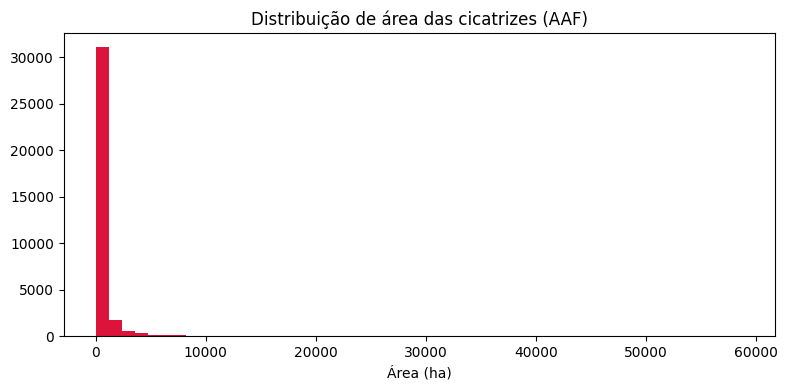

In [247]:
# Estatísticas de área (ha)
print(gdf_aaf_metric['area_ha'].describe())

plt.figure(figsize=(8, 4))
plt.hist(gdf_aaf_metric['area_ha'], bins=50, color='crimson')
plt.xlabel('Área (ha)')
plt.title('Distribuição de área das cicatrizes (AAF)')
plt.tight_layout()
plt.show()


In [248]:
# Os maiores eventos registrados (top 10)

gdf_aaf_metric.nlargest(10, 'area_ha')[['nome_uc', 'event_year', 'event_date', 'area_ha', 'bioma']]

,nome_uc,event_year,event_date,area_ha,bioma
21017,APA das Ilhas e Várzeas do Rio Paraná,2021,2021-12-30,58780.900000,NaN
36300,REBIO do Guaporé,2024,2024-10-08,56931.982888,AMAZÔNIA
29129,APA Meandros do Rio Araguaia,2024,2024-09-13,56873.214083,CERRADO
35699,PARNA dos Campos Amazônicos,2024,2024-09-20,55580.247468,AMAZÔNIA
9570,PARNA do Viruá,2016,2016-03-04,54917.820000,NaN
15468,PARNA do Araguaia,2019,2019-09-07,53618.610000,NaN
35681,FLONA de Carajás,2024,2024-09-22,52600.288463,AMAZÔNIA
5880,ESEC Serra Geral do Tocantins,2014,2014-09-01,51753.820000,NaN
14688,FLONA de Roraima,2019,2019-04-07,50590.850000,NaN
3169,ESEC Serra Geral do Tocantins,2012,2012-09-20,50168.920000,NaN


In [249]:
# INPE (isolado)

print("Total de focos:", len(df_inpe))
print("\nColunas disponíveis:\n", df_inpe.columns.tolist())

Total de focos: 57341032

Colunas disponíveis:
 ['latitude', 'longitude', 'data_pas', 'satelite', 'pais', 'estado', 'municipio', 'bioma', 'numero_dias_sem_chuva', 'precipitacao', 'risco_fogo', 'id_area_industrial', 'frp', 'file_year']


bioma
Amazônia          26841997
Cerrado           19957418
Caatinga           4005780
Mata Atlântica     3535225
Pantanal           2833791
Pampa               166638
NaN                    183
Name: count, dtype: int64


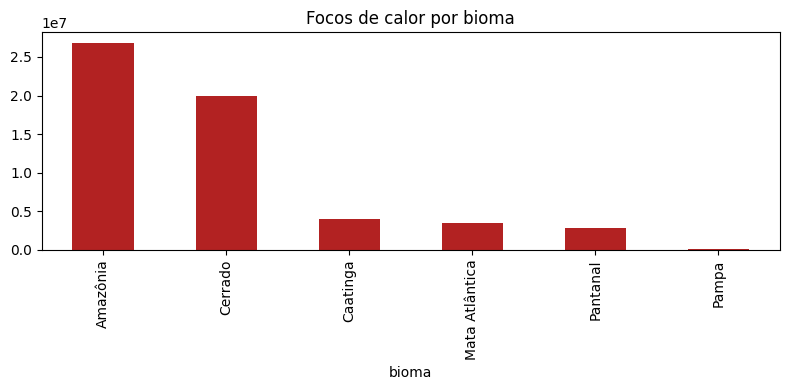

In [250]:
# Distribuição por bioma

print(df_inpe['bioma'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
df_inpe['bioma'].value_counts().plot(kind='bar', color='firebrick')
plt.title('Focos de calor por bioma')
plt.tight_layout()
plt.show()

file_year
2003     966656
2004    1149637
2005    1075006
2006     678258
2007    1153803
2008     642397
2009     427119
2010    1103840
2011     516137
2012    2562540
2013    1301523
2014    1855400
2015    2638964
2016    1982628
2017    2864700
2018    1826081
2019    4070300
2020    5212990
2021    4435088
2022    4590402
2023    4676341
2024    8144823
2025    3466399
Name: count, dtype: int64


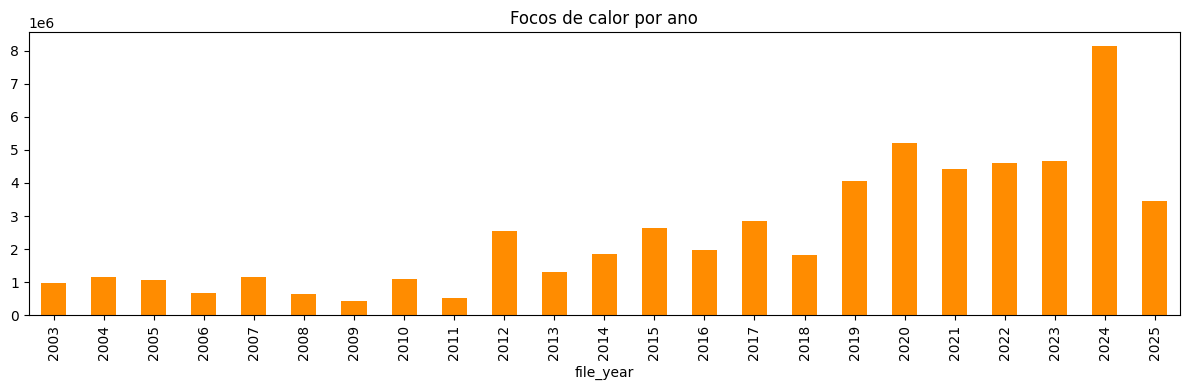

In [251]:
# Distribuição por ano

focos_por_ano = df_inpe['file_year'].value_counts().sort_index()
print(focos_por_ano)

plt.figure(figsize=(12, 4))
focos_por_ano.plot(kind='bar', color='darkorange')
plt.title('Focos de calor por ano')
plt.tight_layout()
plt.show()

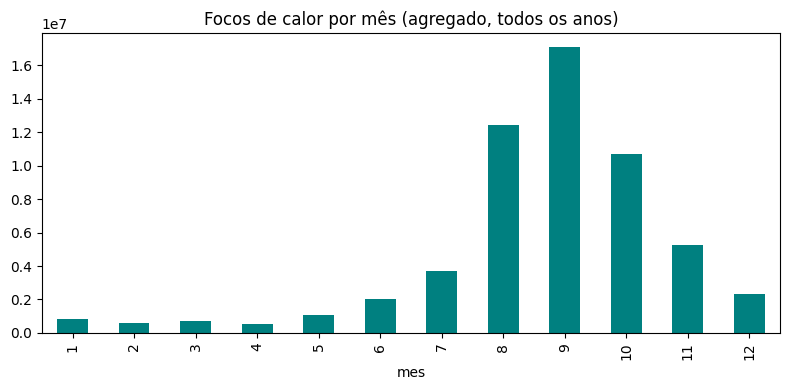

In [252]:
# Distribuição por mês (agregado, todos os anos)

df_inpe['data_pas'] = pd.to_datetime(df_inpe['data_pas'], errors='coerce')
df_inpe['mes'] = df_inpe['data_pas'].dt.month

focos_por_mes = df_inpe['mes'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
focos_por_mes.plot(kind='bar', color='teal')
plt.title('Focos de calor por mês (agregado, todos os anos)')
plt.tight_layout()
plt.show()

In [253]:
# Top 15 municípios com mais focos

print(df_inpe['municipio'].value_counts().head(15))

municipio
CORUMBÁ               1146950
ALTAMIRA              1140716
SÃO FÉLIX DO XINGU    1100813
PORTO VELHO            843645
LÁBREA                 750836
NOVO PROGRESSO         645764
APUÍ                   626128
COLNIZA                556647
POCONÉ                 528258
CÁCERES                445631
LAGOA DA CONFUSÃO      408080
PORTEL                 394612
ITAITUBA               360751
NOVO ARIPUANÃ          349585
PACAJÁ                 316694
Name: count, dtype: int64


In [ ]:
# Estatísticas de FRP

print(df_inpe['frp'].describe())
print("\nNulos em frp:", df_inpe['frp'].isna().sum(), f"({df_inpe['frp'].isna().sum()/len(df_inpe)*100:.1f}%)")

count    3.418620e+07
mean     3.614549e+01
std      8.131311e+01
min     -2.100000e+01
25%      4.600000e+00
50%      1.140000e+01
75%      3.960000e+01
max      1.329090e+04
Name: frp, dtype: float64

Nulos em frp: 23154831 (40.4%)


In [258]:
# Estatísticas de risco_fogo e numero_dias_sem_chuva

print("Risco de fogo:\n", df_inpe['risco_fogo'].describe())
print("\nNulos em risco_fogo:", df_inpe['risco_fogo'].isna().sum())

print("\nDias sem chuva:\n", df_inpe['numero_dias_sem_chuva'].describe())
print("\nNulos em numero_dias_sem_chuva:", df_inpe['numero_dias_sem_chuva'].isna().sum())

Risco de fogo:
 count    4.545408e+07
mean    -9.983600e+00
std      1.032024e+02
min     -9.990000e+02
25%      6.000000e-01
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: risco_fogo, dtype: float64

Nulos em risco_fogo: 11886953

Dias sem chuva:
 count    4.545408e+07
mean     1.372800e+01
std      1.009013e+02
min     -9.990000e+02
25%      3.000000e+00
50%      8.000000e+00
75%      2.700000e+01
max      8.360000e+02
Name: numero_dias_sem_chuva, dtype: float64

Nulos em numero_dias_sem_chuva: 11886953


In [259]:
# Os focos de maior FRP registrados (top 10)
df_inpe.nlargest(10, 'frp')[['municipio', 'estado', 'bioma', 'data_pas', 'satelite', 'frp']]

,municipio,estado,bioma,data_pas,satelite,frp
1947896,VERA,MATO GROSSO,Amazônia,2004-11-05 14:43:00,TERRA_M-T,13290.9
1948001,VERA,MATO GROSSO,Amazônia,2004-11-05 14:43:00,TERRA_M-T,13290.3
717077,PIMENTEIRAS DO OESTE,RONDÔNIA,Amazônia,2003-09-15 18:26:00,AQUA_M-T,12414.7
54688730,JANDAIA DO SUL,PARANÁ,Mata Atlântica,2025-08-12 16:16:00,NPP-375,12311.3
717087,PIMENTEIRAS DO OESTE,RONDÔNIA,Amazônia,2003-09-15 18:26:00,AQUA_M-T,12311.0
784636,NOVA MARINGÁ,MATO GROSSO,Amazônia,2003-09-26 18:08:00,AQUA_M-T,12131.6
3636879,GAÚCHA DO NORTE,MATO GROSSO,Amazônia,2006-09-09 16:39:00,AQUA_M-T,11777.0
4801862,SÃO JOSÉ DO XINGU,MATO GROSSO,Amazônia,2007-09-30 16:27:00,AQUA_M-T,11499.6
773245,NOVA UBIRATÃ,MATO GROSSO,Cerrado,2003-09-25 14:38:00,TERRA_M-T,11333.9
3013346,SANTA TEREZINHA,MATO GROSSO,Amazônia,2005-10-03 16:17:00,AQUA_M-T,10900.6


In [ ]:
# FRP por satélite — dentro de UC

frp_by_satellite = gdf_inpe_with_cell.groupby('satelite')['frp'].agg(
    total='count',
    nulos=lambda x: x.isna().sum(),
    media='mean',
    mediana='median',
    minimo='min',
    maximo='max'
)

frp_by_satellite['pct_nulo'] = (
    gdf_inpe_with_cell.groupby('satelite')['frp'].apply(lambda x: x.isna().sum() / len(x) * 100)
)

# Total de registros por satélite, para contextualizar o peso de cada um
total_por_satelite = gdf_inpe_with_cell['satelite'].value_counts()
frp_by_satellite['total_registros'] = total_por_satelite

print(frp_by_satellite.sort_values('total_registros', ascending=False))

In [ ]:
# Quantificar valores sentinela -999 em risco_fogo e numero_dias_sem_chuva

print("Valores == -999 em risco_fogo:", (gdf_inpe_with_cell['risco_fogo'] == -999).sum())
print("Valores == -999 em numero_dias_sem_chuva:", (gdf_inpe_with_cell['numero_dias_sem_chuva'] == -999).sum())

# Ver se os -999 se concentram em algum satélite específico
sentinela_por_satelite = (
    gdf_inpe_with_cell[gdf_inpe_with_cell['risco_fogo'] == -999]
    ['satelite'].value_counts()
)
print("\nSatélites com valor sentinela -999 em risco_fogo:\n", sentinela_por_satelite)

# %%
# Substituir sentinela por NaN antes de qualquer estatística

gdf_inpe_with_cell['risco_fogo'] = gdf_inpe_with_cell['risco_fogo'].replace(-999, np.nan)
gdf_inpe_with_cell['numero_dias_sem_chuva'] = gdf_inpe_with_cell['numero_dias_sem_chuva'].replace(-999, np.nan)

print("Risco de fogo (corrigido):\n", gdf_inpe_with_cell['risco_fogo'].describe())
print("\nDias sem chuva (corrigido):\n", gdf_inpe_with_cell['numero_dias_sem_chuva'].describe())

# %%
# Nulos de FRP — são aleatórios ou concentrados em algum satélite específico?

print("Total de registros:", len(gdf_inpe_with_cell))
print("Nulos em frp:", gdf_inpe_with_cell['frp'].isna().sum(),
      f"({gdf_inpe_with_cell['frp'].isna().sum()/len(gdf_inpe_with_cell)*100:.1f}%)")

print("\n% de nulo em frp, por satélite:")
print(
    gdf_inpe_with_cell.groupby('satelite')['frp']
    .apply(lambda x: x.isna().mean() * 100)
    .sort_values(ascending=False)
)

# Pré-processamento

# Modelagem / treinamento

# Avaliação do modelo

# Ajuste de hiperparâmetros

# Validação final